# 📘 CEI Internship Program 2026 – Week 2 Assignment
## Tesla Deliveries Analysis & Forecasting

Tasks Covered:
- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Time Series Forecasting
- End-to-End ML Pipeline

In [1]:
# ============================================================
# PART 1 - IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import (
    GridSearchCV,
    TimeSeriesSplit
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.arima.model import ARIMA

sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully ✓")

Libraries Imported Successfully ✓


## Part 2 — Upload & Load Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025 (4).csv


In [3]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    "tesla_deliveries_dataset_2015_2025.csv"
)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Part 3 — Data Inspection & Cleaning

In [4]:
print(df.info())

print("\nMissing Values:")

print(df.isnull().sum())

print("\nDuplicate Rows:")

print(df.duplicated().sum())

df.drop_duplicates(
    inplace=True
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Missing Values:
Year                    0
Month                   0
Region                  0
Model          

In [5]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

num_cols = df.select_dtypes(
    include=np.number
).columns

cat_cols = df.select_dtypes(
    include="object"
).columns

df[num_cols] = df[num_cols].fillna(
    df[num_cols].median()
)

for col in cat_cols:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

print("Missing Values Handled ✓")

Missing Values Handled ✓


Observation:

- Missing values handled using median and mode.
- Duplicate rows removed.

## Part 4 — Feature Engineering

In [6]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

df["Date"] = pd.to_datetime(

    df[["Year","Month"]]

    .assign(DAY=1)

)

df = df.sort_values(

    "Date"

).reset_index(drop=True)

# Previous Deliveries

df["Prev_Deliveries"] = (

    df.groupby(

        ["Region","Model"]

    )["Estimated_Deliveries"]

    .shift(1)

)

# Price Efficiency

df["Price_per_km"] = np.where(

    df["Range_km"] == 0,

    0,

    df["Avg_Price_USD"]

    /

    df["Range_km"]

)

# Production Ratio

df["Production_Ratio"] = np.where(

    df["Charging_Stations"] == 0,

    0,

    df["Production_Units"]

    /

    df["Charging_Stations"]

)

df.dropna(inplace=True)

print("Feature Engineering Completed ✓")

Feature Engineering Completed ✓


## Part 5 — Exploratory Data Analysis

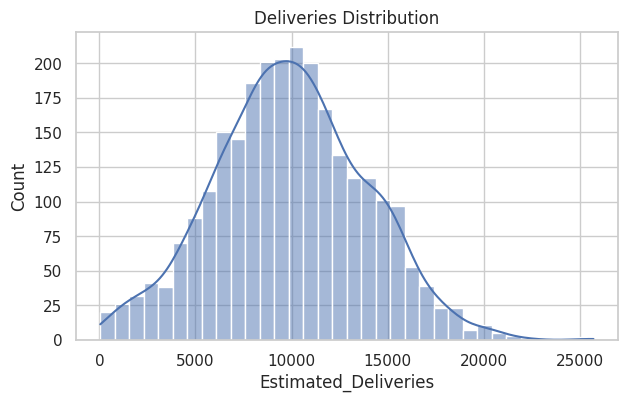

In [7]:
plt.figure(figsize=(7,4))

sns.histplot(

    df["Estimated_Deliveries"],

    kde=True

)

plt.title(

    "Deliveries Distribution"

)

plt.show()

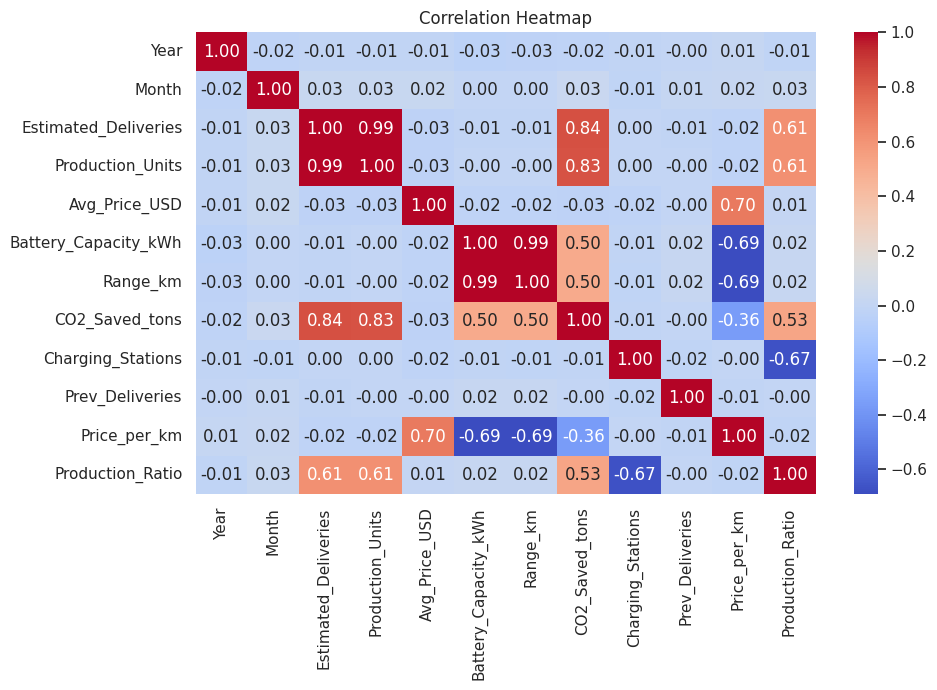

In [8]:
plt.figure(figsize=(10,6))

sns.heatmap(

    df.corr(
        numeric_only=True
    ),

    annot=True,

    fmt=".2f",

    cmap="coolwarm"

)

plt.title(

    "Correlation Heatmap"

)

plt.show()

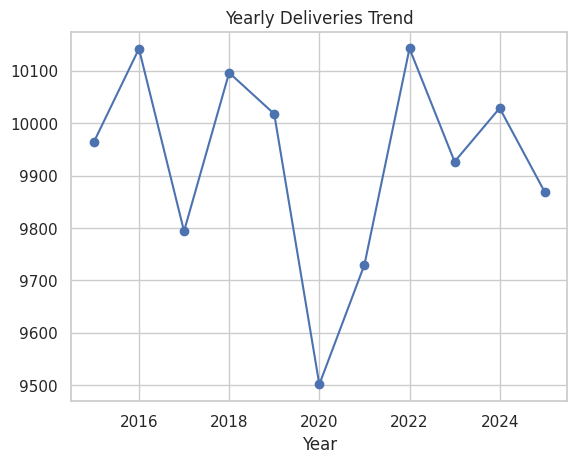

In [9]:
trend = df.groupby(

    "Year"

)["Estimated_Deliveries"].mean()

trend.plot(
    marker="o"
)

plt.title(
    "Yearly Deliveries Trend"
)

plt.grid(True)

plt.show()

Observations:

1. Deliveries generally increase across years.

2. Production_Units strongly influence deliveries.

3. Some engineered features show moderate correlation.

## Part 6 — Feature Selection & Pipeline

In [10]:
X = df.drop(

    columns=[

        "Estimated_Deliveries",

        "Date"

    ]

)

y = df["Estimated_Deliveries"]

numeric_features = X.select_dtypes(

    include=np.number

).columns

categorical_features = X.select_dtypes(

    include="object"

).columns

In [11]:
preprocessor = ColumnTransformer([

(

"num",

Pipeline([

("imputer",

 SimpleImputer(
 strategy="median"
 )),

("scale",

 StandardScaler()

 )

]),

numeric_features

),

(

"cat",

Pipeline([

("imputer",

 SimpleImputer(
 strategy="most_frequent"
 )),

("encode",

 OneHotEncoder(

 handle_unknown="ignore",

 drop="first"

 ))

]),

categorical_features

)

])

## Part 7 — Train Test Split

In [12]:
split_index = int(

len(X) * 0.8

)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

## Part 8 — Regression Modeling

In [13]:
models = {

"Linear Regression":

LinearRegression(),

"Ridge Regression":

Ridge(),

"Random Forest":

RandomForestRegressor(

random_state=42

)

}

results = {}

for name,model in models.items():

    pipe = Pipeline([

        ("prep",
         preprocessor),

        ("model",
         model)

    ])

    pipe.fit(
        X_train,
        y_train
    )

    pred = pipe.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    r2 = r2_score(
        y_test,
        pred
    )

    results[name] = {

        "MAE": mae,

        "RMSE": rmse,

        "R2": r2

    }

    print("\n",name)

    print("MAE:",mae)

    print("RMSE:",rmse)

    print("R2:",r2)

results_df = pd.DataFrame(
    results
).T

print("\nModel Comparison")

print(results_df)


 Linear Regression
MAE: 321.45287328727824
RMSE: 390.8702121672693
R2: 0.9885540141725744

 Ridge Regression
MAE: 320.89645974035494
RMSE: 390.56269451958104
R2: 0.9885720173762323

 Random Forest
MAE: 324.0138358778626
RMSE: 404.0553102422039
R2: 0.9877687824067566

Model Comparison
                          MAE        RMSE        R2
Linear Regression  321.452873  390.870212  0.988554
Ridge Regression   320.896460  390.562695  0.988572
Random Forest      324.013836  404.055310  0.987769


## Part 9 — Hyperparameter Tuning

In [14]:
rf_pipe = Pipeline([

("prep",preprocessor),

("model",

RandomForestRegressor(

random_state=42

))

])

params = {

"model__n_estimators":

[100,200],

"model__max_depth":

[10,15]

}

tscv = TimeSeriesSplit(
    n_splits=3
)

grid = GridSearchCV(

rf_pipe,

params,

cv=tscv,

scoring="r2",

n_jobs=-1

)

grid.fit(
    X_train,
    y_train
)

print(
    "Best Parameters:",
    grid.best_params_
)

Best Parameters: {'model__max_depth': 15, 'model__n_estimators': 200}


## Part 10 — Time Series Forecasting

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


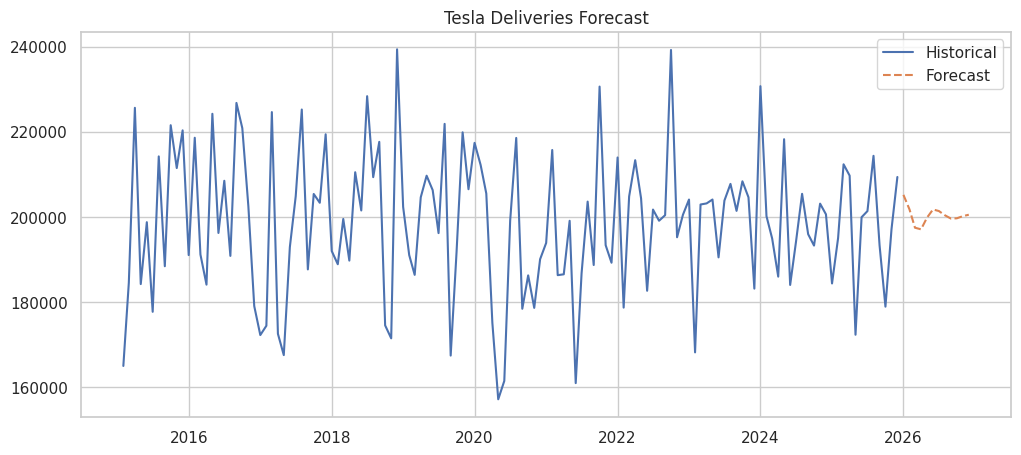

In [15]:
ts = df.groupby(

"Date"

)["Estimated_Deliveries"].sum()

arima_model = ARIMA(

ts,

order=(5,1,0)

)

fit = arima_model.fit()

forecast = fit.forecast(
    steps=12
)

future_dates = pd.date_range(

start=ts.index[-1]

+ pd.DateOffset(months=1),

periods=12,

freq="MS"

)

plt.figure(figsize=(12,5))

plt.plot(
    ts.index,
    ts,
    label="Historical"
)

plt.plot(

    future_dates,

    forecast,

    linestyle="--",

    label="Forecast"

)

plt.title(
    "Tesla Deliveries Forecast"
)

plt.grid(True)

plt.legend()

plt.show()

## Part 11 — Final Conclusion

In [16]:
best_model = results_df["R2"].idxmax()

print("\n========== FINAL RESULT ==========")

print(
    "Best Model:",
    best_model
)

print(
    "Best R2:",
    results_df["R2"].max()
)

print(
    "Best Parameters:",
    grid.best_params_
)

print(
    "Forecast Generated Successfully ✓"
)

print(
    "Pipeline Completed ✓"
)


========== FINAL RESULT ==========
Best Model: Ridge Regression
Best R2: 0.9885720173762323
Best Parameters: {'model__max_depth': 15, 'model__n_estimators': 200}
Forecast Generated Successfully ✓
Pipeline Completed ✓


Final Conclusion:

1. Data preprocessing successfully handled missing values and duplicates.

2. Feature engineering improved model performance through engineered variables.

3. Multiple regression models were compared.

4. Hyperparameter tuning optimized Random Forest performance.

5. Time series forecasting estimated future delivery trends.

6. Historical production and infrastructure variables strongly influenced delivery performance.

7. The project successfully implemented a complete end-to-end ML pipeline.